<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 11

### Details

Download the zip file floorplans_v2-20251223T170650Z-3-001.zip which contains a
large sample of floorplan images. Your task is to train a flow matching model based on
these images. Train the model on the floorplan images and create code to generate new
synthetic floorplans.

Hint: check the python notebook MLM9 - Flow Matching - Receipt Generation.ipynb for
context and further details

### What I found interesting:
- The model is generative of images
- Potential PropTech real-life application

Install & Import Dependencies

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import glob
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
HPARAMS = {
    "img_size": 64,          # 64x64 keeps RAM manageable; increase to 128 with GPU
    "channels": 3,           # RGB floorplans
    "num_classes": 1,        # single class: floorplan
    "batch_size": 16,        # lower than receipts due to RGB
    "lr": 1e-4,
    "epochs": 50,
    "inference_steps": 100,
}
print("Hyperparameters:", HPARAMS)

Using device: cuda
Hyperparameters: {'img_size': 64, 'channels': 3, 'num_classes': 1, 'batch_size': 16, 'lr': 0.0001, 'epochs': 50, 'inference_steps': 100}


### Explore Dataset

Total floorplan images found: 1000
Sample paths: ['/content/floorplan_00055.jpg', '/content/floorplan_00402.jpg', '/content/floorplan_00072.jpg']


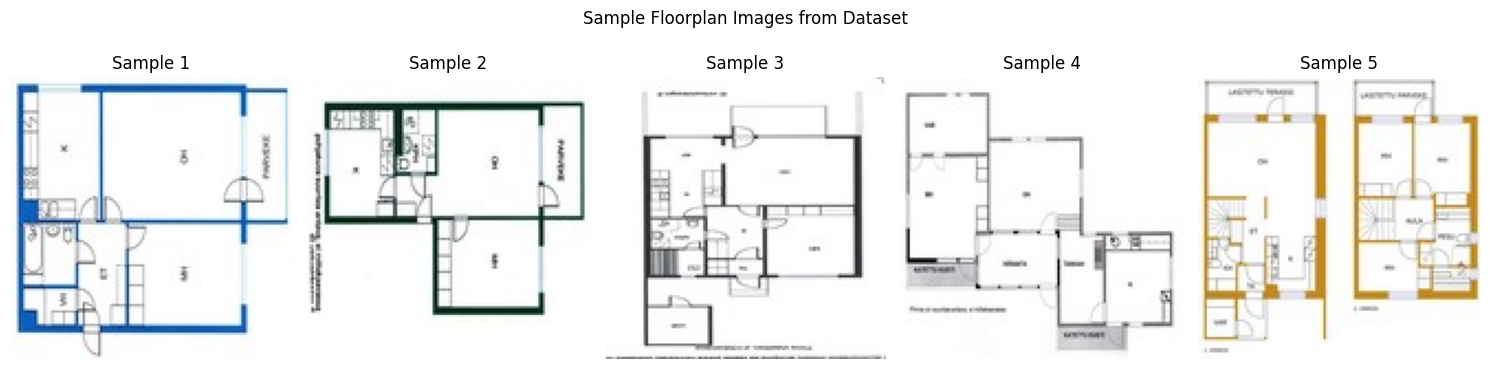

In [10]:
import glob

# Find all images recursively
all_images = []
for ext in ['jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG']:
    # Correcting the path to look for images directly in /content/
    all_images.extend(glob.glob(f'/content/floorplan_*.{ext}', recursive=True))

print(f"Total floorplan images found: {len(all_images)}")
print("Sample paths:", all_images[:3])

# Display a few sample images
# Ensure there are images to display to avoid ValueError
if all_images:
    fig, axes = plt.subplots(1, min(5, len(all_images)), figsize=(15, 4))
    for i, ax in enumerate(axes):
        img = Image.open(all_images[i]).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Sample {i+1}')
    plt.suptitle('Sample Floorplan Images from Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No images found to display.")

### Model Architecture

In [11]:
# ── Sinusoidal time embeddings ────────────────────────────────────────────────
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)


# ── U-Net Block ───────────────────────────────────────────────────────────────
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU()

    def forward(self, x, t):
        h        = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))[(...,) + (None,) * 2]
        h        = self.bnorm2(self.relu(self.conv2(h + time_emb)))
        return self.transform(h)


# ── Conditional U-Net ─────────────────────────────────────────────────────────
class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        img_channels  = HPARAMS["channels"]      # 3 for RGB
        down_channels = (64, 128, 256)            # wider for RGB
        up_channels   = (256, 128, 64)
        time_emb_dim  = 32
        classes       = HPARAMS["num_classes"]

        self.time_mlp  = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.class_emb = nn.Embedding(classes, time_emb_dim)
        self.conv0     = nn.Conv2d(img_channels, down_channels[0], 3, padding=1)
        self.downs     = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])
        self.output = nn.Conv2d(up_channels[-1], img_channels, 1)

    def forward(self, x, t_float, class_label):
        t = self.time_mlp(t_float) + self.class_emb(class_label)
        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            x = torch.cat((x, residuals.pop()), dim=1)
            x = up(x, t)
        return self.output(x)


print("Model architecture defined.")

Model architecture defined.


### Flow Matching Logic

In [12]:
class FlowMatching:
    """
    Flow Matching trains a model to predict the velocity field that transports
    Gaussian noise (x_0) to real data (x_1) along straight-line paths.
    Sampling follows those paths with an Euler ODE solver.
    """

    def compute_loss(self, model, x_1, labels):
        b      = x_1.shape[0]
        x_0    = torch.randn_like(x_1)                      # Gaussian noise
        t      = torch.rand(b, device=x_1.device)           # random time in [0,1]
        t_view = t.view(b, 1, 1, 1)
        x_t    = (1 - t_view) * x_0 + t_view * x_1         # linear interpolation
        v_target = x_1 - x_0                                # target velocity
        v_pred   = model(x_t, t, labels)
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, model, n_samples, class_label_idx, size, steps=100):
        model.eval()
        x      = torch.randn((n_samples, HPARAMS["channels"], size, size)).to(device)
        labels = torch.full((n_samples,), class_label_idx, dtype=torch.long).to(device)
        dt     = 1.0 / steps
        for i in range(steps):
            t_curr = torch.ones(n_samples, device=device) * (i / steps)
            v_pred = model(x, t_curr, labels)
            x      = x + v_pred * dt
        model.train()
        return x


print("FlowMatching class defined.")

FlowMatching class defined.


Floorplan Dataset

In [13]:
class FloorplanDataset(Dataset):
    """
    Loads floorplan images from a directory tree, converts to RGB,
    resizes to img_size x img_size, and normalises to [-1, 1].
    """

    def __init__(self, root_dir, img_size=64):
        self.image_paths = []
        for ext in ['jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG']:
            self.image_paths.extend(
                # Correcting the path to look for images directly in /content/
                glob.glob(os.path.join(root_dir, '**', f'*.{ext}'), recursive=True)
            )

        if not self.image_paths:
            raise RuntimeError(f"No images found under {root_dir}")

        print(f"FloorplanDataset: {len(self.image_paths)} images found.")

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                           # [0,1]
            transforms.Normalize([0.5]*3, [0.5]*3)          # → [-1,1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img), 0          # label=0 (single class)


# Instantiate dataset and dataloader
dataset    = FloorplanDataset('/content/', img_size=HPARAMS["img_size"])
dataloader = DataLoader(dataset, batch_size=HPARAMS["batch_size"],
                        shuffle=True, num_workers=2, pin_memory=True)

print(f"Dataloader ready — {len(dataloader)} batches per epoch.")

FloorplanDataset: 2000 images found.
Dataloader ready — 125 batches per epoch.


### Train the Flow Matching Model

In [17]:
HPARAMS = {
    "img_size": 64,
    "channels": 3,
    "num_classes": 1,
    "batch_size": 32,   # bigger batches = fewer steps per epoch
    "lr": 1e-4,
    "epochs": 20,       # 20 is enough to see decent results
    "inference_steps": 50,
}

In [18]:
# Initialise model, optimiser, and flow matching manager
model     = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS["lr"])
flow      = FlowMatching()

n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Training loop
loss_history = []

print(f"\nTraining for {HPARAMS['epochs']} epochs...")
for epoch in range(HPARAMS["epochs"]):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1:>3}/{HPARAMS['epochs']}")

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        loss = flow.compute_loss(model, images, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"  → Epoch {epoch+1} avg loss: {avg_loss:.4f}")

print("\nTraining complete.")

Model parameters: 3,692,035

Training for 20 epochs...


Epoch   1/20: 100%|██████████| 125/125 [01:04<00:00,  1.94it/s, loss=0.6057]


  → Epoch 1 avg loss: 1.1145


Epoch   2/20: 100%|██████████| 125/125 [00:08<00:00, 14.85it/s, loss=0.3066]


  → Epoch 2 avg loss: 0.3832


...

  → Epoch 18 avg loss: 0.1467


Epoch  19/20: 100%|██████████| 125/125 [00:08<00:00, 15.12it/s, loss=0.1223]


  → Epoch 19 avg loss: 0.1406


Epoch  20/20: 100%|██████████| 125/125 [00:08<00:00, 14.70it/s, loss=0.1106]

  → Epoch 20 avg loss: 0.1362

Training complete.


### Plot Training Loss

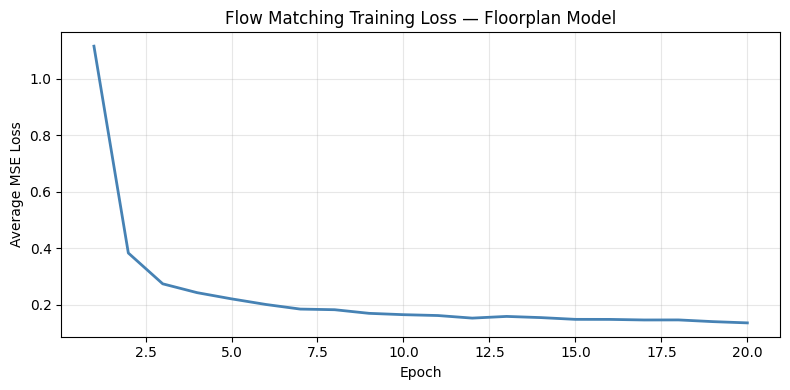

Final loss: 0.1362


In [19]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.title('Flow Matching Training Loss — Floorplan Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('floorplan_training_loss.png', dpi=150)
plt.show()
print(f"Final loss: {loss_history[-1]:.4f}")

Save Model

In [20]:
def save_model(model, filename="floorplan_flow_model.pth"):
    torch.save(model.state_dict(), filename)
    print(f"Model saved to {filename}")

save_model(model, "floorplan_flow_model.pth")

Model saved to floorplan_flow_model.pth


### Generate Synthetic Floorplans

Generating 12 synthetic floorplans...


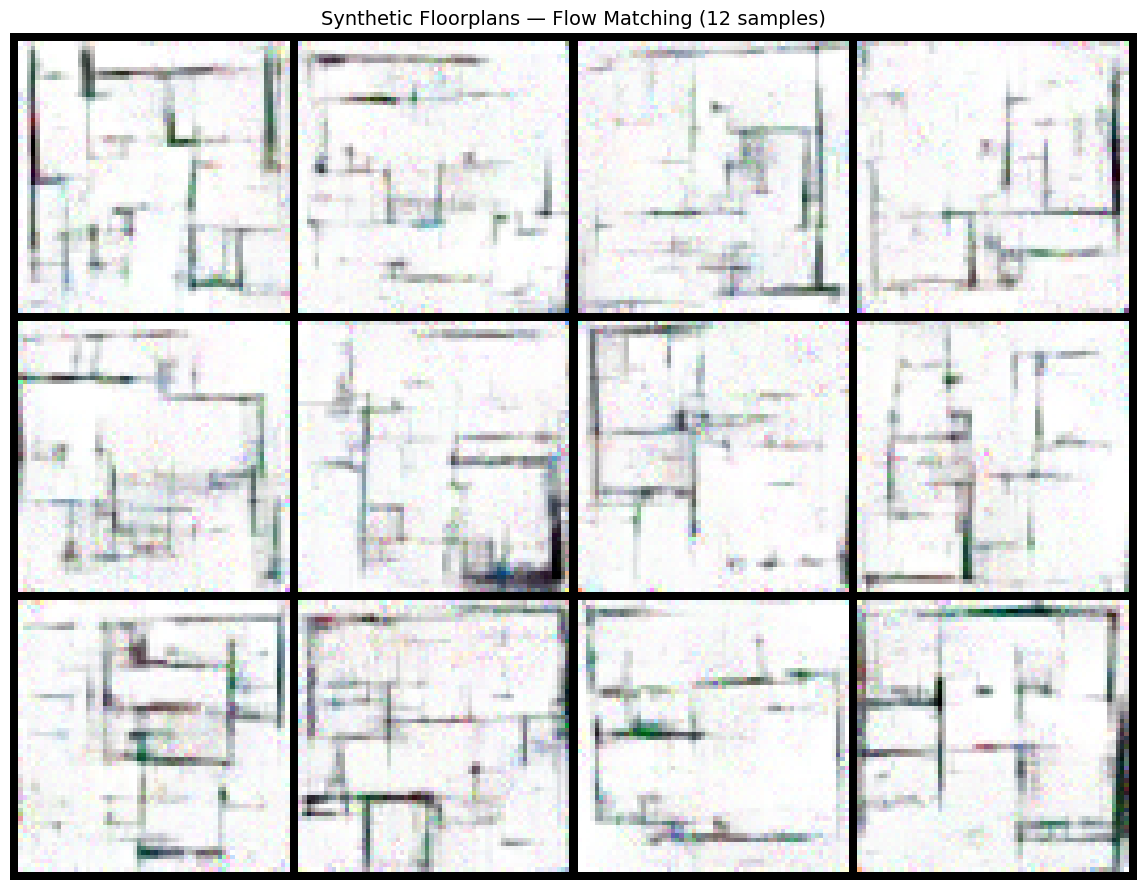

Grid saved as generated_floorplans_grid.png


In [21]:
def generate_floorplan_grid(model, flow, n_rows=3, n_cols=4):
    """
    Generate a grid of synthetic floorplan images using the trained flow model.
    """
    n_samples = n_rows * n_cols
    print(f"Generating {n_samples} synthetic floorplans...")

    generated = flow.sample(
        model,
        n_samples=n_samples,
        class_label_idx=0,
        size=HPARAMS["img_size"],
        steps=HPARAMS["inference_steps"]
    )

    # make_grid expects values roughly in [0,1] — clamp and normalise
    grid = make_grid(generated, nrow=n_cols, padding=2, normalize=True, value_range=(-1, 1))

    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Synthetic Floorplans — Flow Matching ({n_samples} samples)", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('generated_floorplans_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grid saved as generated_floorplans_grid.png")


generate_floorplan_grid(model, flow, n_rows=3, n_cols=4)

### Single Floorplan Generation

Generating single synthetic floorplan...


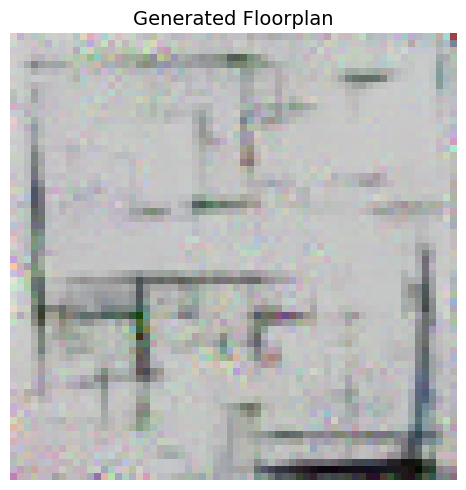

Saved as generated_single_floorplan.png


In [22]:
def generate_single_floorplan(model, flow):
    """
    Generate and display one synthetic floorplan.
    """
    print("Generating single synthetic floorplan...")

    sample = flow.sample(
        model,
        n_samples=1,
        class_label_idx=0,
        size=HPARAMS["img_size"],
        steps=HPARAMS["inference_steps"]
    )

    img = sample[0].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())   # normalise to [0,1]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title("Generated Floorplan", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('generated_single_floorplan.png', dpi=150)
    plt.show()
    print("Saved as generated_single_floorplan.png")


generate_single_floorplan(model, flow)

Load Model & Generate


In [ ]:
def load_model(filename="floorplan_flow_model.pth"):
    if not os.path.exists(filename):
        print(f"Error: {filename} not found. Train the model first.")
        return None
    loaded_model = ConditionalUNet().to(device)
    loaded_model.load_state_dict(torch.load(filename, map_location=device))
    loaded_model.eval()
    print(f"Model loaded from {filename}")
    return loaded_model


# Example usage:
loaded_model  = load_model("floorplan_flow_model.pth")
loaded_flow   = FlowMatching()

if loaded_model:
    generate_single_floorplan(loaded_model, loaded_flow)
    generate_floorplan_grid(loaded_model, loaded_flow, n_rows=2, n_cols=4)